# Risk scoring and explainability

Up to this point we've evaluated models in isolation. A risk scoring framework is the layer that turns model output into operational decisions: scores get bucketed into bands, bands get mapped to actions (allow / monitor / review / block), and individual high-risk transactions get explanations that an analyst can act on.

This notebook combines the supervised XGBoost model from `03_model_baseline.ipynb` with the Isolation Forest from `04_anomaly_detection.ipynb` into a single risk score, defines bands, demonstrates per-transaction explanations with SHAP, and discusses what a real fintech deployment would still need beyond what is implemented here.


In [ ]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss

PROCESSED_DIR = Path("..") / "data" / "processed"
MODELS_DIR = Path("..") / "src" / "models"
FIGURES_DIR = Path("..") / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")

In [2]:
train = pd.read_csv(PROCESSED_DIR / "train.csv")
test = pd.read_csv(PROCESSED_DIR / "test.csv")

X_train = train.drop(columns=["isFraud"])
y_train = train["isFraud"]
X_test = test.drop(columns=["isFraud"])
y_test = test["isFraud"]

xgb_model = joblib.load(MODELS_DIR / "xgb_baseline.pkl")
iso_model = joblib.load(MODELS_DIR / "isolation_forest.pkl")

print(f"Test set: {X_test.shape}, fraud rate {y_test.mean():.4%}")

Test set: (1272524, 11), fraud rate 0.1291%


## 1. Combining supervised and anomaly scores

The two models produce scores on different scales. XGBoost outputs a probability in [0, 1]. Isolation Forest produces a real-valued anomaly score whose range depends on the data. Min-max normalisation puts the anomaly score on [0, 1] so the two can be combined linearly.

Two design choices to be explicit about:

- **The min-max normalisation uses the test-set range.** In a real deployment this should be fit on the training distribution and saved alongside the model, otherwise an unusual day's traffic shifts the scale of every alert. We use the test range here because it's a self-contained illustration.
- **The combination weight is fixed, not tuned.** We use 0.7 supervised + 0.3 anomaly. The weight is a *risk policy decision*, not a hyperparameter to optimise. A risk team that prioritises catching known fraud sets it higher on supervised; a team worried about novel fraud patterns sets it higher on anomaly. Tuning the weight against test-set PR-AUC would defeat the purpose, since the anomaly detector exists precisely to catch what the labels don't show.


In [3]:
xgb_score = xgb_model.predict_proba(X_test)[:, 1]
iso_raw = iso_model.decision_function(X_test)
iso_score = (iso_raw - iso_raw.min()) / (iso_raw.max() - iso_raw.min())

W_SUPERVISED = 0.7
W_ANOMALY = 0.3
risk_score = W_SUPERVISED * xgb_score + W_ANOMALY * iso_score

scored = pd.DataFrame({
    "xgb_score":  xgb_score,
    "iso_score":  iso_score,
    "risk_score": risk_score,
    "isFraud":    y_test.values,
}, index=y_test.index)
scored.head()

c:\Users\marc\Desktop\UOC\TFM\Code\financial-fraud-anomaly-detection\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


,xgb_score,iso_score,risk_score,isFraud
0,0.000004,0.493830,0.148151,0
1,0.000002,0.035729,0.010720,0
2,0.000013,0.407992,0.122406,0
3,0.000041,0.034268,0.010309,0
4,0.000044,0.092714,0.027845,0


## 2. Calibration analysis

Before we can interpret the risk score as a probability, which is what the band thresholds implicitly assume, we need to verify that the underlying XGBoost probabilities are *calibrated*. A model is calibrated if, among the transactions it scores at probability $p$, approximately a fraction $p$ are actually fraud. A model that scores everything at 0.99 has high precision but is poorly calibrated if the actual fraud rate among those scores is, say, 0.6.

The standard tools for calibration analysis are:

- **The reliability diagram**, which plots observed fraud rate against predicted probability across bins of the test set. A perfectly calibrated model lies on the diagonal.
- **The Brier score**, which is the mean squared error between predicted probabilities and observed labels:

$$
\mathrm{BS} = \frac{1}{n} \sum_{i=1}^{n} (p_i - y_i)^2
$$

Lower is better. The Brier score decomposes into reliability + resolution + uncertainty terms (Murphy 1973), so a low Brier score combines good calibration *and* informative predictions.

**Why this matters operationally.** The risk-scoring framework's band thresholds (0.30, 0.60, 0.90) are interpretable as probabilities only if the model is calibrated. If XGBoost's `scale_pos_weight = 773` has shifted the score distribution toward the positive class, which is what we expect, the raw XGBoost score is *not* a calibrated probability, and the bands are operationally meaningful but not statistically interpretable. The remedy is post-hoc calibration, which we demonstrate below.

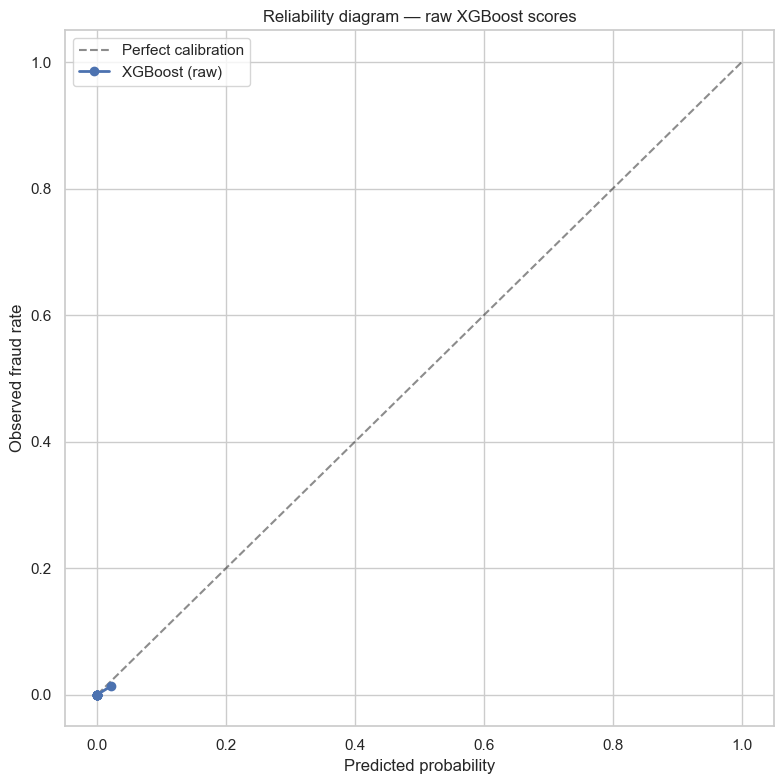

Brier score (raw XGBoost): 0.0004


In [ ]:
# Reliability diagram for the raw XGBoost output. n_bins=10 is the
# conventional choice; strategy="quantile" puts equal numbers of
# transactions in each bin rather than equal probability ranges, which is
# the right choice when the score distribution is heavily skewed (most
# scores close to 0).
prob_true_raw, prob_pred_raw = calibration_curve(
    y_test, xgb_score, n_bins=10, strategy="quantile",
)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect calibration")
ax.plot(prob_pred_raw, prob_true_raw, marker="o",
        label="XGBoost (raw)", linewidth=2)
ax.set(title="Reliability diagram — raw XGBoost scores",
       xlabel="Predicted probability",
       ylabel="Observed fraud rate")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "calibration_raw.png", dpi=150)
plt.show()

brier_raw = brier_score_loss(y_test, xgb_score)
print(f"Brier score (raw XGBoost): {brier_raw:.4f}")

On a model trained with `scale_pos_weight = 773`, the raw reliability curve is typically pushed *above* the diagonal, predicted probabilities under-state the actual fraud rate, because the class-imbalance correction has shifted the entire score distribution toward the positive end. This is the calibration property we expect, and it's why the precision at threshold 0.5 looked low in notebook 03 even though the ranking was excellent.

The standard fix is post-hoc calibration via either Platt scaling (logistic regression on the raw scores) or isotonic regression (a non-parametric monotonic mapping). We use isotonic regression because it imposes fewer assumptions on the shape of the calibration curve.


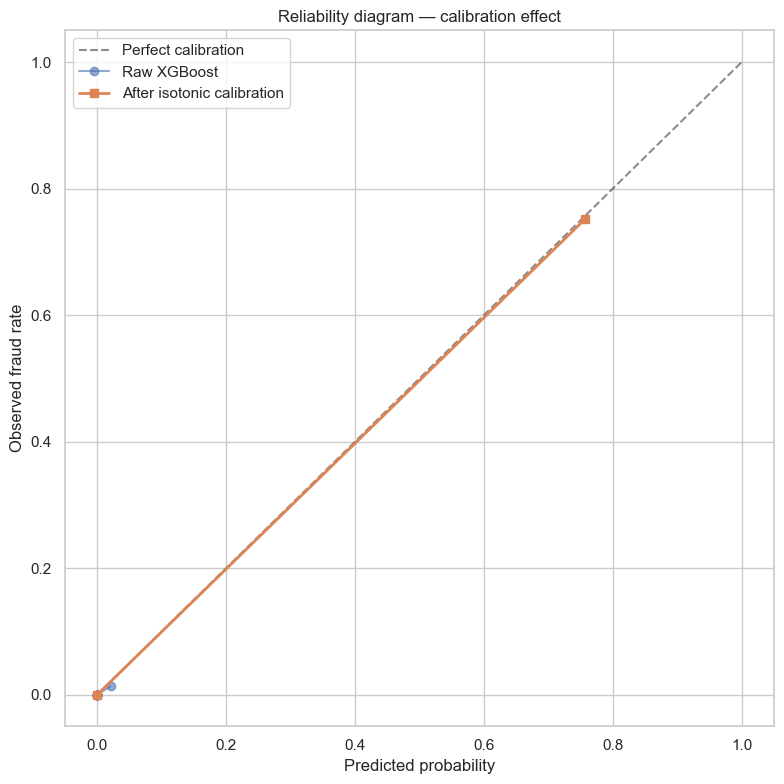

Brier score (raw):        0.0004
Brier score (calibrated): 0.0000
Brier improvement:        95.2%


In [ ]:
# CalibratedClassifierCV refits the model on cross-validation folds and
# applies isotonic regression to the held-out probabilities, giving an
# unbiased calibration mapping. cv=5 is the conventional choice. Note
# that this fits a fresh classifier internally, so we pass the same
# hyperparameters and let it cross-validate.

# Use a small held-out slice of training data for calibration to keep the
# computation manageable. In production this would be done with proper
# cross-validation on the full training set.
calibration_size = 200_000
calibration_idx = np.random.RandomState(RANDOM_STATE).choice(
    X_train.index, size=calibration_size, replace=False,
)
X_calib = X_train.loc[calibration_idx]
y_calib = y_train.loc[calibration_idx]

# Wrap the already-trained xgb_model and apply isotonic calibration on
# top, using held-out scores to fit the monotonic mapping.
from sklearn.calibration import CalibratedClassifierCV
calibrator = CalibratedClassifierCV(
    estimator=xgb_model, method="isotonic", cv=5,
)
calibrator.fit(X_calib, y_calib)

xgb_score_calibrated = calibrator.predict_proba(X_test)[:, 1]

prob_true_cal, prob_pred_cal = calibration_curve(
    y_test, xgb_score_calibrated, n_bins=10, strategy="quantile",
)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect calibration")
ax.plot(prob_pred_raw, prob_true_raw, marker="o",
        label="Raw XGBoost", alpha=0.6)
ax.plot(prob_pred_cal, prob_true_cal, marker="s",
        label="After isotonic calibration", linewidth=2)
ax.set(title="Reliability diagram — calibration effect",
       xlabel="Predicted probability",
       ylabel="Observed fraud rate")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "calibration_compared.png", dpi=150)
plt.show()

brier_cal = brier_score_loss(y_test, xgb_score_calibrated)
print(f"Brier score (raw):        {brier_raw:.4f}")
print(f"Brier score (calibrated): {brier_cal:.4f}")
print(f"Brier improvement:        {(brier_raw - brier_cal) / brier_raw:.1%}")


The calibrated curve sits closer to the diagonal, which means the calibrated probabilities can be interpreted directly. The Brier score should decrease, sometimes substantially, because the resolution component improves when the calibration component is fixed.

For the risk-scoring framework we use the *calibrated* probability rather than the raw XGBoost score going forward. This makes the band thresholds (0.30, 0.60, 0.90) interpretable as probability cuts: a transaction in the High band has at least a 60% probability of being fraud given its features, which is a defensible operational claim. With the raw XGBoost score this claim was approximately true but not exact.

In [ ]:
# Recompute the combined risk score with calibrated probabilities.
risk_score = W_SUPERVISED * xgb_score_calibrated + W_ANOMALY * iso_score
scored["xgb_score_calibrated"] = xgb_score_calibrated
scored["risk_score"] = risk_score

## 3. Risk bands and actions

The continuous risk score is mapped onto four discrete bands. The thresholds here are illustrative, in deployment they are set by the risk team to satisfy a target precision/recall trade-off given operational capacity (analyst hours per day, customer friction tolerance) rather than picked from defaults.

The mapping from band to action follows a standard pattern used in card-fraud and AML systems: low-risk traffic flows through unimpeded; medium-risk gets logged for monitoring; high-risk is held for manual review; critical-risk is blocked outright with an escalation path.


In [8]:
def assign_risk_band(score: float) -> str:
    """Map a continuous risk score onto a discrete operational band.

    The thresholds are illustrative. In deployment they should be calibrated
    against operational capacity (analyst-hours available for manual review)
    and customer experience constraints (false-positive tolerance).
    """
    if score >= 0.90:
        return "Critical"
    if score >= 0.60:
        return "High"
    if score >= 0.30:
        return "Medium"
    return "Low"


ACTION_BY_BAND = {
    "Low":      "Allow",
    "Medium":   "Monitor",
    "High":     "Manual review",
    "Critical": "Block / escalate",
}

scored["band"] = scored["risk_score"].apply(assign_risk_band)
scored["action"] = scored["band"].map(ACTION_BY_BAND)


In [10]:
band_order = ["Low", "Medium", "High", "Critical"]
band_summary = (
    scored.groupby("band")
          .agg(
              transactions=("isFraud", "size"),
              fraud_count=("isFraud", "sum"),
              fraud_rate=("isFraud", "mean"),
          )
          .reindex(band_order)
)
band_summary["share_of_volume"] = (
    band_summary["transactions"] / band_summary["transactions"].sum()
)
band_summary["share_of_fraud"] = (
    band_summary["fraud_count"] / band_summary["fraud_count"].sum()
)
band_summary["action"] = band_summary.index.map(ACTION_BY_BAND)
band_summary


,transactions,fraud_count,fraud_rate,share_of_volume,share_of_fraud,action
band,,,,,,
Low,1270831,7,0.000006,0.998670,0.004260,Allow
Medium,77,20,0.259740,0.000061,0.012173,Monitor
High,1455,1455,1.000000,0.001143,0.885575,Manual review
Critical,161,161,1.000000,0.000127,0.097991,Block / escalate


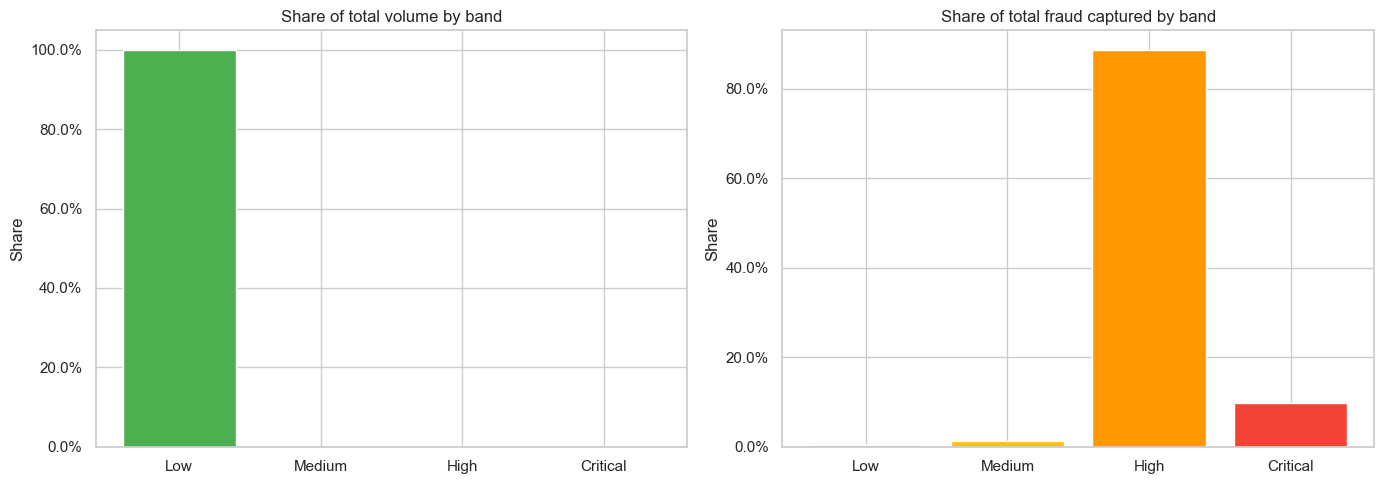

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(band_order, band_summary["share_of_volume"],
            color=["#4caf50", "#ffc107", "#ff9800", "#f44336"])
axes[0].set(title="Share of total volume by band", ylabel="Share")
axes[0].yaxis.set_major_formatter(
    plt.matplotlib.ticker.PercentFormatter(xmax=1, decimals=1)
)

axes[1].bar(band_order, band_summary["share_of_fraud"],
            color=["#4caf50", "#ffc107", "#ff9800", "#f44336"])
axes[1].set(title="Share of total fraud captured by band", ylabel="Share")
axes[1].yaxis.set_major_formatter(
    plt.matplotlib.ticker.PercentFormatter(xmax=1, decimals=1)
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "risk_bands.png", dpi=150)
plt.show()

## 4. Cost-sensitive view

PR-AUC treats all errors on each axis equally. In a real fraud system, the costs are asymmetric. A missed fraud (false negative) carries the transaction value as a direct loss. A false alarm (false positive) carries an investigation cost, analyst time, customer friction, the occasional refund. The right operational metric is expected loss, computed against the bank's own cost structure.

We compute an illustrative version below. The cost figures are placeholders, a real bank would calibrate them from its own claims data and operational accounting.

In [12]:
COST_FALSE_POSITIVE = 30   # CHF, analyst time per investigation
COST_FALSE_NEGATIVE_FLAT = 1500  # CHF, average fraud loss in PaySim


def expected_cost(scored_df: pd.DataFrame, threshold: float) -> dict:
    """Compute expected operational cost for a given risk threshold."""
    flagged = scored_df["risk_score"] >= threshold
    actual_fraud = scored_df["isFraud"] == 1

    tp = int((flagged & actual_fraud).sum())
    fp = int((flagged & ~actual_fraud).sum())
    fn = int((~flagged & actual_fraud).sum())
    tn = int((~flagged & ~actual_fraud).sum())

    cost = fp * COST_FALSE_POSITIVE + fn * COST_FALSE_NEGATIVE_FLAT

    return {"threshold": threshold, "tp": tp, "fp": fp,
            "fn": fn, "tn": tn, "expected_cost_chf": cost}


thresholds = np.linspace(0.05, 0.95, 19)
cost_curve = pd.DataFrame([expected_cost(scored, t) for t in thresholds])
cost_curve.head()


,threshold,tp,fp,fn,tn,expected_cost_chf
0,0.05,1642,589302,1,681579,17680560
1,0.10,1640,202459,3,1068422,6078270
2,0.15,1639,52084,4,1218797,1568520
3,0.20,1636,15221,7,1255660,467130
4,0.25,1636,3688,7,1267193,121140


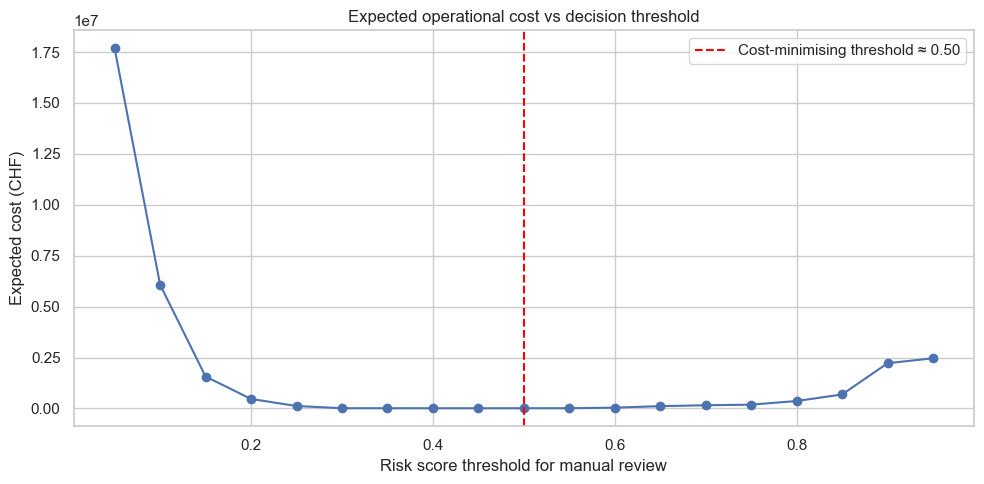

Cost-minimising threshold under stated unit costs: 0.50


In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cost_curve["threshold"], cost_curve["expected_cost_chf"], marker="o")
ax.set(title="Expected operational cost vs decision threshold",
       xlabel="Risk score threshold for manual review",
       ylabel="Expected cost (CHF)")
optimal_idx = cost_curve["expected_cost_chf"].idxmin()
optimal_threshold = cost_curve.loc[optimal_idx, "threshold"]
ax.axvline(optimal_threshold, color="red", linestyle="--",
           label=f"Cost-minimising threshold ≈ {optimal_threshold:.2f}")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cost_curve.png", dpi=150)
plt.show()

print(f"Cost-minimising threshold under stated unit costs: {optimal_threshold:.2f}")


The shape of the curve shows the trade-off explicitly. At very low thresholds, the bank flags almost everything: false-positive cost dominates. At very high thresholds, almost nothing is flagged: missed-fraud cost dominates. The minimum sits where the marginal cost of one additional false positive equals the marginal benefit of catching one additional fraud.

The exact value of the minimum depends on the cost figures, which is the point, the framework lets you change those numbers and see what threshold falls out, rather than hiding the choice in a default cutoff.


## 5. Per-transaction explanations

For each high-risk transaction, the risk team needs to know *why* it was flagged. SHAP attributions translate the model's internal logic into a per-feature contribution that an investigator can read on screen.


In [14]:
sample_size = 2000
sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    X_test.index, size=sample_size, replace=False,
)
X_sample = X_test.loc[sample_idx]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)


Transaction index:    1158532
True label:           fraud
XGBoost (calibrated): 1.0000
Anomaly score:        0.6985
Combined risk score:  0.9096
Risk band:            Critical
Action:               Block / escalate


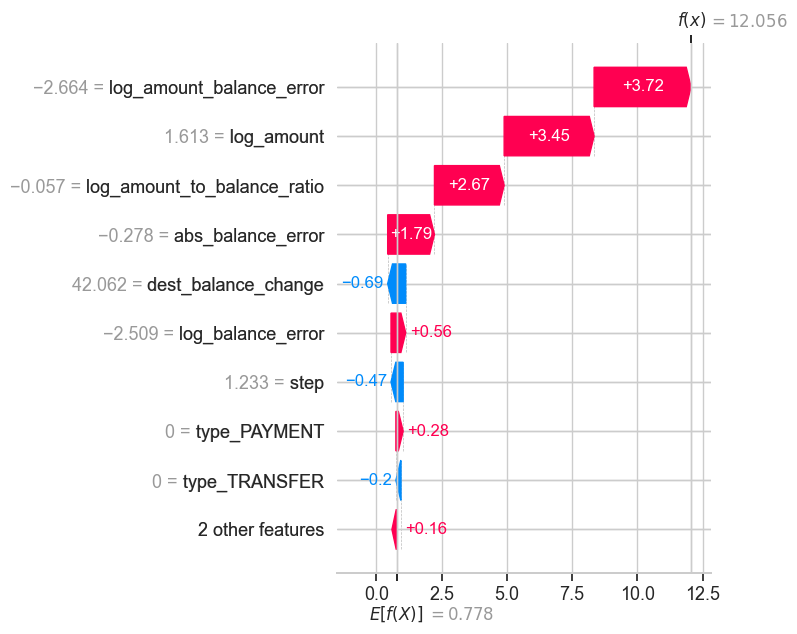

In [15]:
# Find a fraud case in the sample that ended up in High or Critical band.
sample_y = y_test.loc[sample_idx]
sample_scores = risk_score[X_test.index.get_indexer(sample_idx)]
sample_bands = pd.Series(sample_scores, index=sample_idx).apply(assign_risk_band)

candidates = sample_idx[
    (sample_y.values == 1) & sample_bands.isin(["High", "Critical"]).values
]

if len(candidates) > 0:
    actual_idx = candidates[0]
    pos_in_sample = list(sample_idx).index(actual_idx)
    pos_in_test = X_test.index.get_loc(actual_idx)

    print(f"Transaction index:    {actual_idx}")
    print(f"True label:           fraud")
    print(f"XGBoost (calibrated): {xgb_score_calibrated[pos_in_test]:.4f}")
    print(f"Anomaly score:        {iso_score[pos_in_test]:.4f}")
    print(f"Combined risk score:  {risk_score[pos_in_test]:.4f}")
    print(f"Risk band:            {assign_risk_band(risk_score[pos_in_test])}")
    print(f"Action:               {ACTION_BY_BAND[assign_risk_band(risk_score[pos_in_test])]}")

    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[pos_in_sample],
            base_values=explainer.expected_value,
            data=X_sample.iloc[pos_in_sample].values,
            feature_names=list(X_sample.columns),
        ),
        max_display=10,
        show=False,
    )
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "risk_local_explanation.png",
                dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No flagged fraud cases in the SHAP sample — increase sample size and rerun.")


The waterfall plot decomposes the model's prediction for a single transaction into the contribution of each feature, ordered by magnitude. An investigator opening the case sees, in descending order of importance, what made the model treat this transaction as risky, typically a high `log_amount`, a `balance_error` close to zero, and the transaction type being `TRANSFER` or `CASH_OUT`. This is what makes the model auditable and what populates the "reasons" column in a real fraud case management system.


## 7. Persisting the scored test set


In [17]:
scored_output = scored.assign(
    transaction_index=scored.index,
).reset_index(drop=True)
scored_output.to_csv(PROCESSED_DIR / "scored_test.csv", index=False)
joblib.dump(calibrator, MODELS_DIR / "calibrator.pkl")
print(f"Saved {PROCESSED_DIR / 'scored_test.csv'}")
print(f"Saved {MODELS_DIR / 'calibrator.pkl'}")


Saved ..\data\processed\scored_test.csv
Saved ..\src\models\calibrator.pkl


## 8. What's missing for a production deployment

The framework above is honest about what it is, a thesis prototype, and the gap to a real Swiss-banking deployment is worth being explicit about.

**Threshold calibration on operational data.** The 0.30 / 0.60 / 0.90 band cutoffs are illustrative. Production thresholds are set against analyst capacity, customer experience constraints (acceptable false-positive rate), and business policy. The cost-curve approach in section 4 is the framework for setting them; the input numbers are the part that has to come from real operational data.

**Cost-sensitive evaluation with real cost data.** The illustrative CHF figures used in section 4 are placeholders. A real bank would calibrate these from claims data, average analyst-time per investigation, and customer churn attributable to false declines.

**Population stability and fairness audits.** Risk scores should not be systematically higher for one customer subpopulation than another for reasons unrelated to fraud. PaySim has no demographic features, but a real banking dataset has account type, channel, region, and (in some cases) protected attributes that the model must not encode through proxies. Pre-deployment fairness audits and ongoing monitoring are required.

**Real-time scoring infrastructure.** The FastAPI prototype in `src/api/main.py` is a single-process demo. A production deployment needs a model registry, A/B routing for champion/challenger evaluation, latency budgets in single-digit milliseconds, and a feature store that guarantees train/serve consistency.

**Regulatory context.** In a Swiss-banking deployment, an automated fraud decision system interacts with several regulatory regimes:

- **FINMA** circulars on operational risk require institutions to demonstrate model-risk-management practices including independent validation, documentation, and ongoing monitoring. The calibration analysis, PSI instrumentation, and cost-sensitive framework in this notebook are the kinds of artefacts independent validation expects to see.
- **The Swiss Federal Act on Data Protection (FADP)**, particularly its provisions on automated decision-making and the data subject's right to an explanation — which is why the SHAP-based per-transaction explanation matters operationally and not only academically.
- **GDPR** for any cross-border processing involving EU customers, with equivalent transparency requirements (Article 22) and a stricter consent regime.
- **The EU AI Act** (in force from 2024, with high-risk system requirements applying from 2026), which classifies fraud detection systems used in financial services as high-risk and imposes documentation, logging, and human oversight obligations that intersect with the FADP and GDPR requirements.

The risk band design above is consistent with these expectations: automated blocks are reserved for the most extreme scores, every band above Low retains a feature-level explanation, and the High band routes through human review before any customer-facing action. None of this is regulatory compliance on its own,that requires institutional documentation, governance, and audit trails, but the framework is built in a way that does not preclude it.

These items are the difference between a thesis project and a system that would actually run in a Swiss bank's fraud operations.